In [18]:
from numpy import count_nonzero,arange,array,dot,asarray,zeros,apply_along_axis,around,sort,shape,savetxt,array_equal,max,argmin,argmax,fill_diagonal,ones,argsort,std,mean,median,diag,random,diff
from matplotlib.pyplot import plot,figure,title,legend,xlabel,ylabel,grid,axvline,savefig,imshow,show,scatter,hist,bar,subplot,subplots,text,axhline,stem,pie,axis
import pandas as pd
import scipy.io as sio 
import seaborn as sns #graficas mas bonitas
from statsmodels.tsa.stattools import adfuller,grangercausalitytests,acovf,acf # grenger covarianza, adfuller
import statsmodels.api as sm # gráfica correlacion cruzada
from math import sqrt,dist # distancia euclidiana 
from dtaidistance import dtw 
from aeon.distances import msm_distance

# Importar datos

In [19]:
df = pd.read_csv('matriz_series.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Serie1  301 non-null    float64
 1   Serie2  301 non-null    float64
 2   Serie3  301 non-null    float64
 3   Serie4  301 non-null    float64
 4   Serie5  301 non-null    float64
 5   Serie6  301 non-null    float64
dtypes: float64(6)
memory usage: 14.2 KB


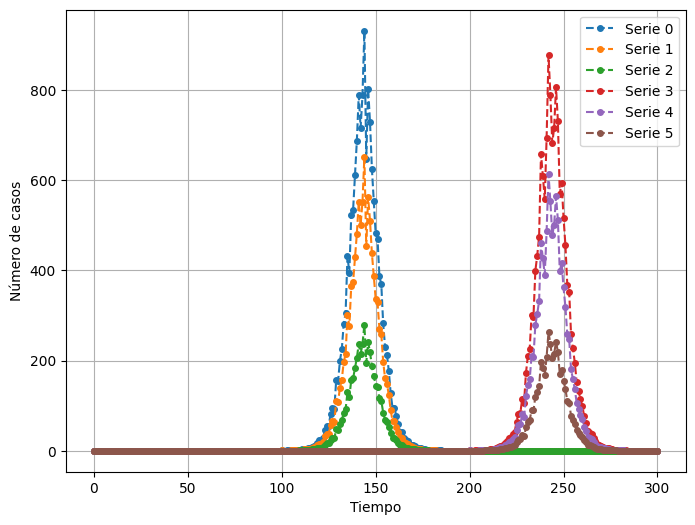

In [20]:
matriz = df.to_numpy()
#Graficar series
figure(figsize = (8,6))
grid()
xlabel("Tiempo")
ylabel("Número de casos")
for i in range(0,6):
    plot(matriz[:,i], marker="o", markersize=4, linestyle="--", label="Serie "+str(i))
legend()

# Calcular distancias entre cada par de series

In [21]:
#Matriz para almacenar la distancia euclidiana entre cada par de series de tiempo
def matriz_euclid(series):
    #n es el número de observaciones de cada serie de tiempo
    #m es el número de series de tiempo
    n,m = shape(series)
    #Matriz de ceros para guardar las distancias entre cada par de series de tiempo
    M = zeros((m,m))
    for i in range(0,m):
        for j in range(i+1,m):
            M[i,j] = dist(series[:,i], series[:,j])
    return M+M.T


#Matriz para almacenar la función DTW entre cada par de series de tiempo
def matriz_dtw(series):
    M = dtw.distance_matrix_fast(series.T)
    return M 


#Matriz para almacenar la métrica MSM entre las series de tiempo
def matriz_msm(series):
    #n es el número de observaciones de cada serie de tiempo
    #m es el número de series de tiempo
    n,m = shape(series)
    #Matriz de ceros para guardar las distancias entre cada par de series de tiempo
    M = zeros((m,m))
    for i in range(0,m):
        for j in range(i+1,m):
            M[i,j] = msm_distance(series[:,i], series[:,j])
    return M+M.T


#Funciones para obtener la correlación cruzada máxima entre cada par de series de tiempo
#Calcular la correlación entre dos series de tiempo con un desfase o lag h (Cross-correlation)
def cross_cor_h(x,y,h):
    #Cálculo de la correlación cruzada
    ro_xy = sm.tsa.stattools.ccf(x, y, adjusted = False, nlags = h)
    return ro_xy

#h_sup nos indica la cantidad de unidades de tiempo que se tomarán para aplicar los desfases de las series
#h_inf es el mínimo desfase que se considerará
def selec_h(x, y, h_inf, h_sup):
    #Vamos a evaluar la correlación con valores de h desde h_inf a h_sup
    #Arreglo con las correlaciones desde 0 hasta h_sup
    arr_corr = cross_cor_h(x, y, h_sup)
    #Del arreglo anterior sólo tomaremos las correlaciones con un h mayor o igual que h_inf
    corr_cut = arr_corr[h_inf:h_sup+1].tolist()
    corr_max = max(corr_cut)
    h_max = corr_cut.index(max(corr_cut))+h_inf
    return corr_max,h_max

#h_sup nos indica la máxima cantidad de días que se considerarán como desfase en las series de tiempo
def mat_cor_h_sync(data_series, umbral, h_inf=0, h_sup=15, diff_param=False):
    #Si diff=True entonces se va a diferenciar cada columna de la matriz de datos
    if diff_param == True:
        data = apply_along_axis(diff,0,data_series)
    else:
        data = data_series.copy()
    #Dimensiones de la matriz de datos
    n,m = shape(data)
    #Matriz de valores de h con los que se alcanzó la correlación cruzada máxima
    H_mat = zeros((m,m))
    #Matriz de correlaciones máximas
    cor_mat = zeros((m,m))
    #Obtener valores de correlación entre cada par de series de tiempo
    for i in range(0,m):
        for j in range(i+1,m):
            cor_mat_i_j,H_mat_i_j = selec_h(data[:,i],data[:,j],h_inf,h_sup)
            cor_mat_j_i,H_mat_j_i = selec_h(data[:,j],data[:,i],h_inf,h_sup)
            #Determinar el máximo de entre las componentes i,j y j,i de la matriz de correlaciones
            if abs(cor_mat_i_j) >= abs(cor_mat_j_i):
                #Si el desfase es no mayor que el umbral entonces sí se agrega a la salida
                if H_mat_i_j <= umbral and cor_mat_i_j > 1.96/sqrt(n-H_mat_i_j):
                    cor_mat[i,j],H_mat[i,j] = cor_mat_i_j,1
            else:
                #Si el desfase es no mayor que el umbral entonces sí se agrega a la salida
                if H_mat_j_i <= umbral and cor_mat_j_i > 1.96/sqrt(n-H_mat_j_i):
                    cor_mat[i,j],H_mat[i,j] = cor_mat_j_i,1
    #Hacer las matrices simétricas porque en este caso no se distinguen direcciones
    cor_mat_sim = cor_mat+cor_mat.T
    H_mat_sim = H_mat+H_mat.T
    #En la diagonal se colocan 1's denotando que una serie de tiempo alcanza la correlación máxima 
    #al compararse consigo misma con un desfase de 0
    fill_diagonal(cor_mat_sim, 1)
    fill_diagonal(H_mat_sim, 0)
    return cor_mat_sim,H_mat_sim

Text(0.5, 1.0, 'Distancia euclidiana entre las series de tiempo')

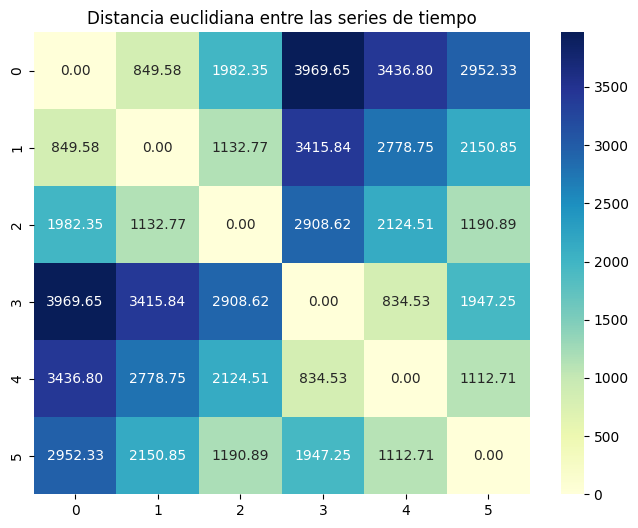

In [22]:
M_euc = matriz_euclid(matriz)
figure(figsize = (8,6))
sns.heatmap(M_euc, annot=True, cmap="YlGnBu", fmt=".2f")
title("Distancia euclidiana entre las series de tiempo")

Text(0.5, 1.0, 'Función DTW entre las series de tiempo')

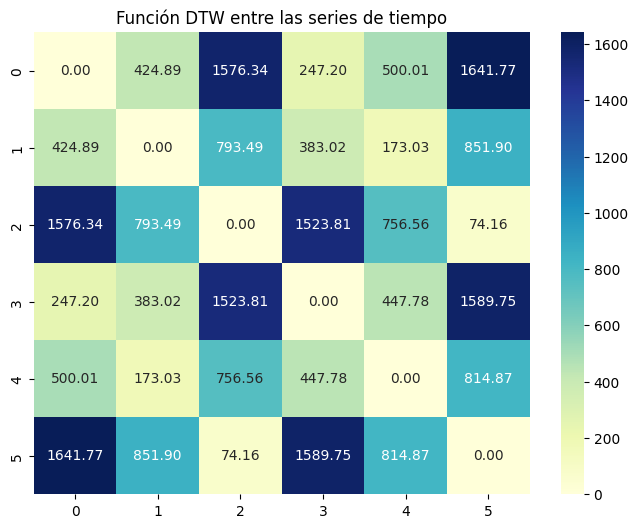

In [23]:
M_dtw = matriz_dtw(matriz)
figure(figsize = (8,6))
sns.heatmap(M_dtw, annot=True, cmap="YlGnBu", fmt=".2f")
title("Función DTW entre las series de tiempo")

Text(0.5, 1.0, 'Métrica MSM entre las series de tiempo')

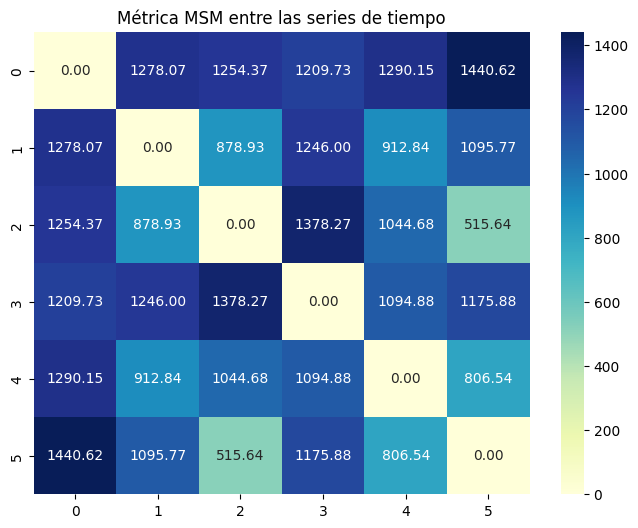

In [24]:
M_msm = matriz_msm(matriz)
figure(figsize = (8,6))
sns.heatmap(M_msm, annot=True, cmap="YlGnBu", fmt=".2f")
title("Métrica MSM entre las series de tiempo")

Text(0.5, 1.0, 'Correlaciones cruzadas máximas entre las series de tiempo')

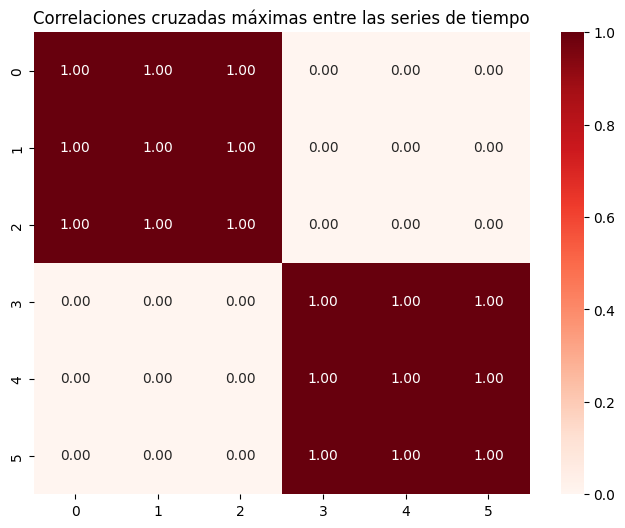

In [25]:
#Aplicación de correlación cruzada
corr_mat,sync_mat = mat_cor_h_sync(matriz, umbral=2, h_inf=0, h_sup=5, diff_param=True)
#Correlaciones cruzadas máximas encontradas entre las series de tiempo tomando lags entre h_inf y h_sup
figure(figsize = (8,6))
sns.heatmap(corr_mat, annot=True, cmap="Reds", fmt=".2f")
title("Correlaciones cruzadas máximas entre las series de tiempo")

Text(0.5, 1.0, 'Matriz de sincronicidad entre las series de tiempo')

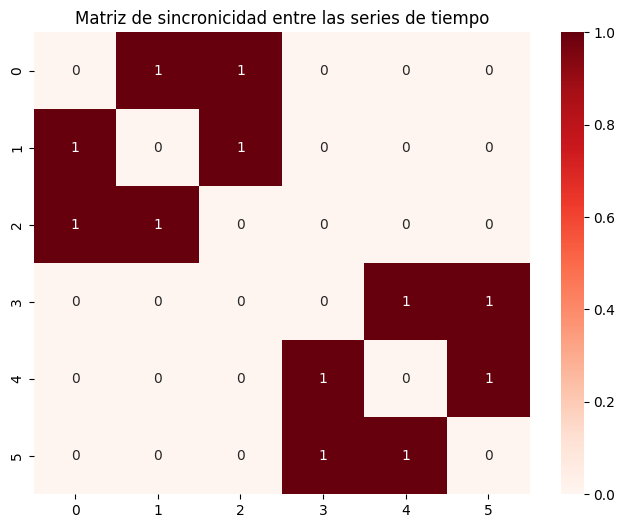

In [26]:
#Matriz que indica qué series de tiempo presentaron su correlación cruzada máxima con un desfase entre h_inf y el umbral
figure(figsize = (8,6))
sns.heatmap(sync_mat.astype(int), annot=True, cmap="Reds", fmt="d")
title("Matriz de sincronicidad entre las series de tiempo")